In [1]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


# RAG
## Цель работы

Создание RAG системы, которая сможет отвечать на вопросы, основываясь на предоставленных PDF,которые являются доукументами для планировки квартир, а также дизайнерские книги для пойска концепций для визуальной части комнат. Процесс включает предобработку текста, создание векторной базы, визуализацию данных, реализацию различных методик и моделей для RAG.

### Что такое эмбеддинги?

Эмбеддинги (от англ. embedding — "встраивание") — это числовые представления объектов (например, слов, предложений, изображений или других данных) в многомерном пространстве.

Основная идея заключается в том, что каждому объекту ставится в соответствие вектор фиксированной длины, который сохраняет семантическую или структурную информацию об этом объекте. Эти векторы позволяют работать с данными в машинном обучении и глубоком обучении, так как алгоритмы могут оперировать только числовыми значениями.

Например:
1. Для слов эмбеддинг может отражать их смысл, контекст использования и связь с другими словами.
2. Для изображений эмбеддинг может представлять ключевые признаки, такие как цвета, формы или текстуры.
3. Для предложений эмбеддинг может учитывать не только слова, но и их порядок, а также общую тематику.

Важным свойством эмбеддингов является то, что близкие по смыслу объекты будут иметь похожие векторы, то есть они будут находиться близко друг к другу в многомерном пространстве.

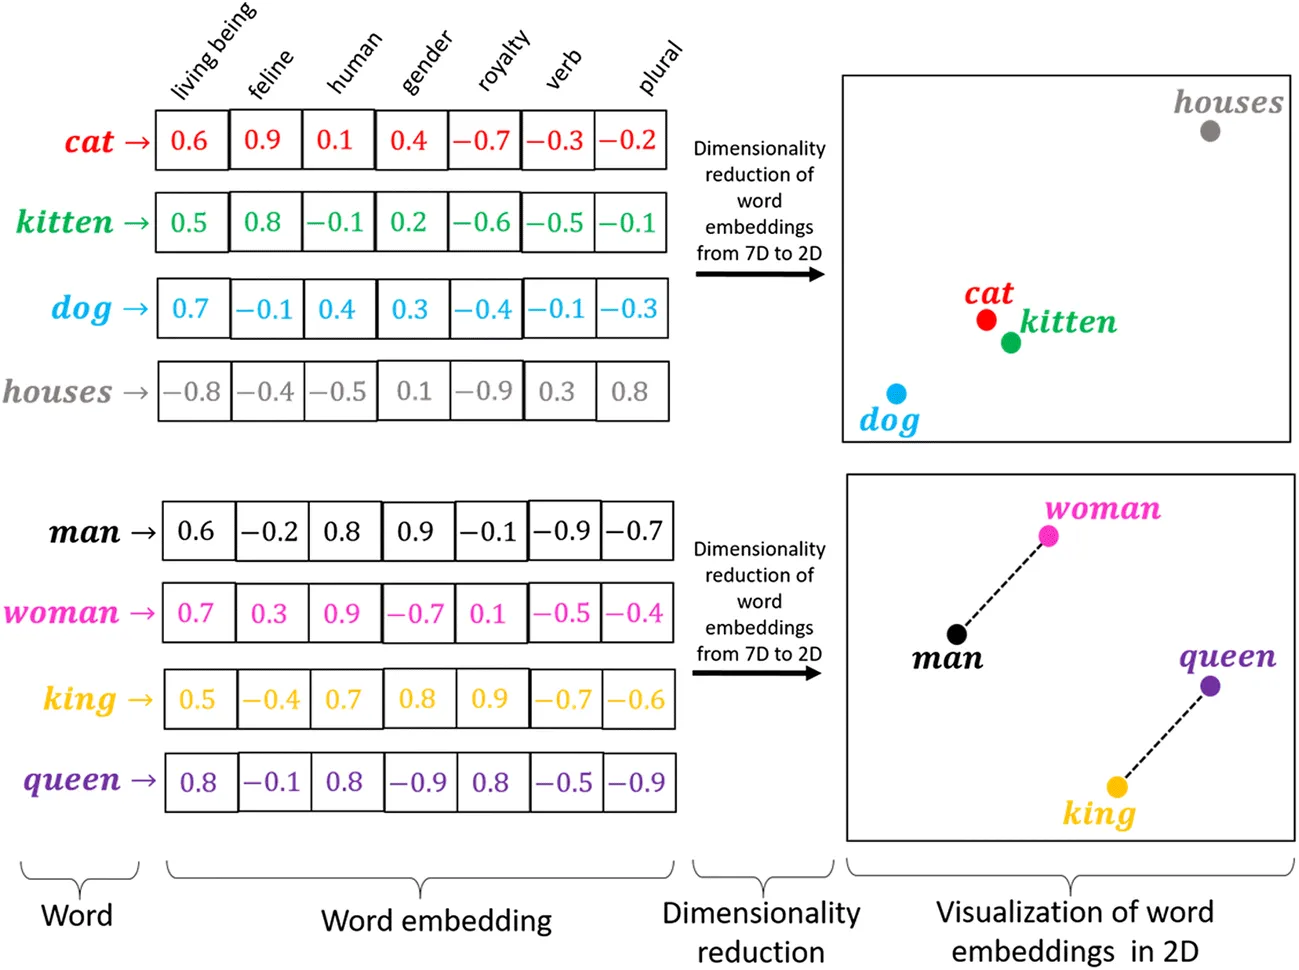

Векторные пространства представляют собой математические конструкции, состоящие из векторов. Векторы можно представить как точки в пространстве, которые характеризуются направлением и длиной. В контексте эмбеддингов каждый вектор служит числовым отображением объекта, предоставляя его уникальное представление.
Размерность вектора указывает на количество координат, используемых для описания этого вектора.

В эмбеддингах большая размерность часто подразумевает более точное и детализированное описание данных. Например, для текстовых эмбеддингов векторное пространство может включать тысячи измерений.

Чтобы определить, насколько похожи или различны объекты, в эмбеддингах измеряется расстояние между векторами. Для этого используются метрики, такие как Евклидово расстояние или косинусная мера сходства. Эти метрики позволяют оценить близость объектов в векторном пространстве, что является ключевым для многих алгоритмов машинного обучения, таких как классификация или кластеризация.
Наиболее интуитивно понятным способом измерения расстояния является Евклидово расстояние. В эмбеддингах оно вычисляется как корень квадратный из суммы квадратов разностей соответствующих элементов двух векторов.

Для двух векторов $x$ и $y$ Евклидово расстояние $d_E$ определяется формулой:

$$d_E(x,y)=\sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$


 подходит для измерения абсолютных различий, но может быть менее эффективным в высокоразмерных пространствах из-за проклятия размерности [1].

Манхэттенское расстояние, иногда более подходящее для определенных типов данных, это расстояние измеряется как сумма абсолютных разностей их компонентов. Определяется как:

$$d_{\text{Manhattan}}(x,y)=\sum_{i=1}^{n} \lvert x_i - y_i \rvert$$



Ещё одна из популярных метрик в эмбеддингах это косинусное сходство. Косинусное сходство измеряет косинус угла между двумя векторами. Если угол между векторами мал, косинус приближается к 1, что указывает на высокое сходство. Математически оно выражается как:

$$ \operatorname{cos\_{sim}}(x,y)
= \frac{\langle x, y \rangle}{\lVert x\rVert_2\\lVert y\rVert_2}
= \frac{\sum_{i=1}^{d} x_i y_i}
       {\sqrt{\sum_{i=1}^{d} x_i^2}\\sqrt{\sum_{i=1}^{d} y_i^2}}$$



### Откуда взялись эмбеддинги?

Идея перевода текста в числа, чтобы сделать текст более машиночитаемым, не нова. Исследователи занимаются этим с первых дней развития вычислительной техники (примерно с 1950 года).
Хотя за прошедшие годы было придумано бесчисленное множество способов цифрового представления текста, самые современные из них создаются на основе LLM.
Их эффективность объясняется тем, что в процессе обучения LLM тренируются на (очень) хороших числовых представлениях текстов. Слои, генерирующие эти представления, можно выделить из модели и использовать отдельно. Результатом этого процесса является модель текстового эмбеддинга.

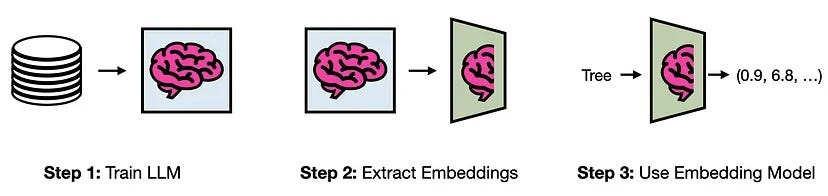

### Что такое RAG?
RAG, или Retrieval-Augmented Generation, [2, 3, 4] — это гибридная архитектура для задач обработки естественного языка (NLP), которая сочетает в себе преимущества двух подходов: поиска информации (retrieval-based) и генерации текста (generation-based). Этот подход был предложен в 2020 году исследователями из Facebook AI Research (FAIR) и стал популярным благодаря своей способности эффективно решать задачи, связанные с доступом к внешним источникам знаний.

Основная идея заключается в том, чтобы дополнить модель генерации текста (например, GPT) доступом к внешним базам данных или документам, чтобы она могла использовать актуальную информацию для создания более точных и информативных ответов. Это особенно полезно в случаях, когда модель не имеет достаточного объема знаний о конкретной теме (например, новейших событиях или специализированных данных).

### Как работает RAG?

RAG состоит из двух ключевых компонентов:

1. Ретриевер (Retriever):

   1.1. Это модуль, который отвечает за поиск релевантной информации из внешнего источника данных (например, базы документов, статей, базы знаний или интернета).

   1.2. Ретриевер использует такие методы, как семантический поиск (semantic search), чтобы найти документы или фрагменты текста, которые наиболее соответствуют запросу пользователя.

   1.3. Обычно для этого используются модели, обученные на представлении текста в виде векторов (например, BERT, Sentence-BERT или другие эмбеддинги).

2. Генератор (Generator):

   2.1. Это модуль, который создает финальный ответ на основе запроса пользователя и найденной релевантной информации.

   2.2. Генератор может быть реализован с использованием мощных языковых моделей, таких как GPT, T5 или других архитектур, способных генерировать текст на основе входных данных.

   2.3. Генератор получает на вход как исходный запрос пользователя, так и информацию, найденную ретриевером, и комбинирует их для создания осмысленного и точного ответа.

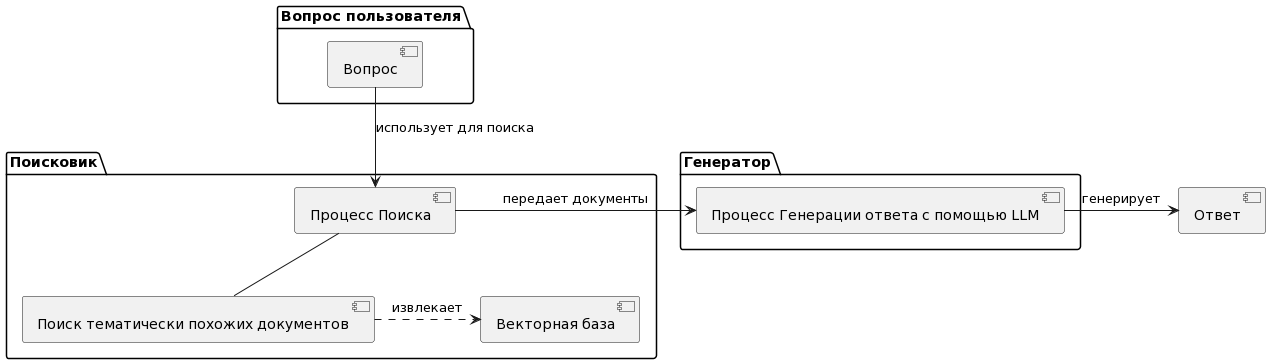

### Основные принципы работы с Retrieval

Ключевым в построении RAG системы является компонент поиска информации.  Retrieval-компонент выполняет задачу поиска наиболее релевантных фрагментов текста или документов на основе входного запроса. Для этого используются два основных механизма:

1. Embedding модели. Преобразуют текстовые данные в числовые представления (векторы), которые могут быть использованы для семантического сравнения.
    
2. Векторная база данных. Хранит векторные представления текстов и обеспечивает быстрый поиск ближайших соседей.

Обычно retrieval строят на документах в формате pdf или подобных. Существуют библиотеки, которые позволяют считывать текстовую информацию их файлов, например **pdfplumber**, **PyPDF2**, **pdfminer.six**, однако после прочтения данных файлов текстовые данные содержат в себе существенное количество разметочных символов. У данного последствия есть как плюсы, так и минусы. Если требуется восстановить внутреннюю структуру файла, например, иерархию глав, пунктов, метаданные (номера страниц, номера пунктов) и т.п., то данная разметка является мостом для восстановления структуры. Есть даже ответвление в данной тематике, которое набирает популярность – это использование ViLM (Vision-and-Language Model), чтобы модель сама восстановила структуру документов в текстовом виде. Если же данный аспект в решении поставленной задаче не имеет важности, то эти разметочные данные требуется очистить, поскольку они являются шумом.

Также первоначальные документы нужно разбить на отдельные фрагменты. Данный этап реализуется научно-итеративным методом. Текст документа можно разбить по предложениям, по абзацам, используя метаинформацию, чанками с фиксированным количеством символов как с перекрытием, так и без (окно перекрытия – это то, на сколько одна часть чанка пересекается с другими).

Далее особенно важным пунктом является выбор модели для построения векторной базы. В данном вопросе требуется обратить внимание на языки в документах. Модель должна быть восприимчива к языку либо быть многоязычной. Также если документы содержат в себе термины или профессионализмы, то требуется искать модель устойчивую к данным словам либо самостоятельно реализовывать fine-tuning на специализированном корпусе данных.



## Практическая часть (baseline)


В данном baseline’е используется следующий стек:

1. `pdfplumber` – извлечение текста из PDF-файлов;
2. `re` – для извлечение метаданных (например, название кодекса, статья, пункт) из текста с помощью регулярных выражений;
3. `sentence-transformers` – создание векторных представлений текста (эмбеддингов);
4. `numpy` – работа с векторами;
5. `faiss` – эффективное хранение и поиск векторов;
6. `transformers` – загрузка и использование языковых моделей (например, Mistral, Falcon);
7. `auto-gptq` – работа с квантизированными моделями `GPTQ`;
8. `torch` – работа с тензорами и GPU;
9. `umap-learn` – снижение размерности векторов для визуализации.
    




# Предобработка текста

# Базовые правила расстановки мебели


In [2]:
DESIGN_RULES_DOCUMENTS = [
    {
        "text": """
        ПРАВИЛА ДИЗАЙНА ИНТЕРЬЕРА - РАССТАНОВКА МЕБЕЛИ

        1. НЕ ЗАГОРАЖИВАТЬ ОКНА И ИСТОЧНИКИ СВЕТА
        ❌ Чего избегать:
        - Ставить высокую мебель перед окном
        - Вешать темные плотные шторы
        ✅ Что делать:
        - Оставлять оконный проем свободным
        - Использовать легкие занавеси
        - Низкую мебель под окном ставить можно

        2. НЕ ПЕРЕКРЫВАТЬ ПРОХОДЫ И ДВЕРНЫЕ ПРОЕМЫ
        ❌ Чего избегать:
        - Ставить мебель, перекрывающую пути движения
        ✅ Что делать:
        - Оставлять проходы 70-80 см минимум
        - Создавать четкие "дорожки"

        3. НЕ ПРИЖИМАТЬ ВСЮ МЕБЕЛЬ К СТЕНАМ
        ❌ Чего избегать:
        - Вся мебель строго по периметру
        ✅ Что делать:
        - Использовать плавающую планировку
        - Диван спинкой к центру комнаты

        4. НЕ ЗАГРОМОЖДАТЬ ЦЕНТР КОМНАТЫ
        ❌ Чего избегать:
        - Много мебели в центре
        ✅ Что делать:
        - В центре только ключевая композиция
        - Диван + стол + кресла в гостиной

        5. УЧИТЫВАТЬ УДОБСТВО ПОЛЬЗОВАНИЯ
        ❌ Чего избегать:
        - Кровать к холодной стене
        - Монитор напротив окна
        ✅ Что делать:
        - Продумывать ежедневное использование
        - Розетки рядом с кроватью и столом

        6. СОЗДАВАТЬ ВИЗУАЛЬНУЮ ГАРМОНИЮ
        ❌ Чего избегать:
        - Мебель разных стилей
        - Много мелких предметов
        ✅ Что делать:
        - Единая стилистика
        - Несколько крупных предметов + акценты
        """,
        "file_name": "Правила_дизайна_интерьера.pdf"
    }
]

## Извлечение текста из PDF файлов

Первым этапом – вытащим всю текстовую информацию из документов и сформируем массив со словарями, которые хранят в себе текста документов. В зависимости от объёма файлов, процесс может занять длительное время. В данном случае около 10 минут.

Выполняем парсинг всего текстового содержимого из pdf документов, вместе с внутренней разметкой pdf'ок.


In [3]:
# Сначала установим базовые зависимости без gptqmodel
!pip install -q pdfplumber sentence-transformers umap-learn faiss-cpu

# Попробуем установить gptqmodel отдельно с дополнительными опциями
print("Установка gptqmodel...")
!pip install -q "gptqmodel>=0.0.3" --no-deps
!pip install -q "auto-gptq>=0.7.0"

# Установим transformers с правильной версией
!pip install -q "transformers>=4.41.0"

# Установим недостающие зависимости для gptqmodel
!pip install -q logbar device-smi>=0.5.1 maturin>=1.9.4 pypcre>=0.2.5 random_word>=1.0.13 tokenicer>=0.0.5

Установка gptqmodel...
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement auto-gptq>=0.7.0 (from versions: 0.0.4, 0.0.5, 0.1.0, 0.2.0, 0.2.1, 0.2.2, 0.3.0, 0.3.1, 0.3.2, 0.5.0, 0.5.1, 0.6.0, 0.7.0, 0.7.1)
ERROR: No matching distribution found for auto-gptq>=0.7.0


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pdfplumber
import os
import shutil

def extract_text_from_pdf(pdf_path):
    text = ""
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() + f" (Страница {page.page_number})\n"
    return text

# Пути к директориям
pdf_drive_dir = "/content/drive/MyDrive/docs"  # ИСТОЧНИК
pdf_dir = "/content/docs"  # НАЗНАЧЕНИЕ

# Создаем целевую директорию, если она не существует
os.makedirs(pdf_dir, exist_ok=True)

# Копируем все файлы из source_dir в target_dir
for filename in os.listdir(pdf_drive_dir):
    src_file = os.path.join(pdf_drive_dir, filename)
    dst_file = os.path.join(pdf_dir, filename)

    # Проверяем, что это файл (а не директория)
    if os.path.isfile(src_file):
        shutil.copy2(src_file, dst_file)  # copy2 сохраняет метаданные
        print(f"Скопирован: {filename}")

# Получаем весь список документов в директории
pdf_files = [os.path.join(pdf_dir, f) for f in os.listdir(pdf_dir) if f.endswith(".pdf")]

# Извлекаем текст
documents = []
for pdf_file in pdf_files:
    text = extract_text_from_pdf(pdf_file)
    documents.append({
        "text": text,
        "file_name": os.path.basename(pdf_file)
    })

documents.extend(DESIGN_RULES_DOCUMENTS)

## Разбиение текста на более мелкие фрагменты


Далее подготовим текста для векторизации. Для этого, как было сказано ранее, можно применять различные методики. В данном случае реализовано разбиение текстов на чанки(смысловые части) с фиксированным размером 1000 и перекрытием 200 (то, на сколько последовательные чанки пересекаются друг с другом).


In [ ]:
from typing import List

def split_text_into_chunks(text: str, chunk_size: int = 1000, overlap: int = 200) -> List[str]:
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

# Разбиение текста на чанки
chunked_documents = [
    {
        "text": chunk,
        "file_name": doc["file_name"]
    }
    for doc in documents
    for chunk in split_text_into_chunks(doc["text"])
    if chunk.strip()
]

# Создание векторной базы

##Выбор модели для создания векторов

Далее, нужно создать векторную базу, прогнав получившиеся текста через модель-эмбеддер. Поскольку текст в документах написан на русском языке, то нужно смотреть либо на отечественные модели, либо на многоязычные.

Одной из наиболее сильных моделей является «multilingual-e5-large». Для знакомства с остальными моделями можно обратиться к следующему источнику [7].

Прогоняем через данную модель получившиеся ранее чанки. На выходе получаем их векторные представления.




In [ ]:
from sentence_transformers import SentenceTransformer

# Загрузка модели (может занять несколько минут)
embedding_model = SentenceTransformer('intfloat/multilingual-e5-large')
print("Модель загружена успешно!")

# Функция для создания эмбеддингов
def create_embeddings(documents):
    embeddings = []
    texts = [doc['text'] for doc in documents]
    vectors = embedding_model.encode(texts, show_progress_bar=True)
    for i, doc in enumerate(documents):
        if 'text' in doc and doc['text'].strip():
            embeddings.append({
                "text": doc['text'],
                "vector": vectors[i]
            })
    return embeddings

# Создание эмбеддингов
embeddings = create_embeddings(chunked_documents)
print(f"Создано {len(embeddings)} эмбеддингов")

## Хранение векторов с использованием FAISS

Далее нам требуется переместить вектора в объект «faiss» который создает индекс для быстрого поиска векторов на основе расстояния между ними.

Теперь, когда у нас есть датасет с эмбеддингами, нам нужен способ поиска по ним. Для этого мы будем использовать специальную структуру данных из 🤗 Datasets, называемую FAISS index. FAISS — это библиотека, предоставляющая эффективные алгоритмы для быстрого поиска и кластеризации эмбеддингов.

Основная идея FAISS состоит в том, чтобы создать специальную структуру данных, называемую index, которая позволяет найти, какие эмбеддинги подобны входным эмбеддингам.

Создать индекс FAISS в 🤗 Datasets очень просто — мы используем функцию Dataset.add_faiss_index() и указываем, какой столбец нашего набора данных мы хотим проиндексировать:

In [ ]:
import faiss
import numpy as np
# Преобразование векторов в NumPy
vectors = [emb['vector'] for emb in embeddings]
vectors = np.array(vectors).astype('float32')
texts = [emb['text'] for emb in embeddings]

# Создание индекса FAISS
index = faiss.IndexFlatL2(vectors.shape[1])  # L2 норма
index.add(vectors)

# Визуализация векторной базы

## Приведение векторов к 2D пространству

Далее, для визуального оценивания, выведем наши вектора в 2D пространстве, чтобы понять, как разнеслись вектора в нашей базе данных. Если можно выделить явно кластеры, с большой долей вероятности модель эмбеддер справилась с поставленной задачей и вектора сохранили смысловой контекст чанков. Поскольку вектора – многомерные, то перед визуализацией нужно ужать пространство до двух или трех мерного. В качестве алгоритма сжатия векторов в baseline’е используется UMAP [8].

После прогона чанков через модель-эмбеддер, каждый чанк состоит из многомерного вектора. Для визуализации каждого чанка на 2D требуется ужать пространство до двумерного.

In [ ]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.01, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(vectors)

plt.figure(figsize=(10, 8))
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange', 'purple', 'brown', 'gray']

for i, file_name in enumerate(set([doc['file_name'] for doc in chunked_documents])):
    short_name = " ".join(file_name.split()[:2])

    indices = [j for j, doc in enumerate(chunked_documents) if doc['file_name'] == file_name]
    plt.scatter(embedding_2d[indices, 0], embedding_2d[indices, 1],
                color=colors[i % len(colors)],
                label=short_name)

plt.title("2D Визуализация векторной базы")
plt.legend()
plt.show()

# Реализация RAG-системы
Реализовываем поиск k ближайших векторов к запросу пользователя.


In [ ]:
def search_relevant_chunks(query, index, texts, top_k=5):
    query_vector = embedding_model.encode([query])[0].astype('float32')
    query_vector = np.expand_dims(query_vector, axis=0)

    distances, indices = index.search(query_vector, top_k)
    relevant_chunks = [texts[i] for i in indices[0]]
    return relevant_chunks

# Генерация ответа с использованием LLM
Подключаем LLM для генерации конечного ответа. В промте модели идет первоначальный запрос пользователя, а также контекст, извлеченный из векторной базы по запросу пользователя.



In [ ]:
# Ячейка 1: Аутентификация
!pip install -q huggingface_hub
from huggingface_hub import login

HF_TOKEN = "Your token"
login(token=HF_TOKEN)

print("✅ Аутентификация успешна!")

In [ ]:
# Установка зависимостей
!pip install -q transformers accelerate torch sentence-transformers faiss-cpu umap-learn matplotlib

# Импорт библиотек
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Optional
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import umap

print(f"PyTorch: {torch.__version__}")
print(f"CUDA доступен: {torch.cuda.is_available()}")

# Конфигурация системы
class RAGConfig:
    """Конфигурация RAG системы"""
    EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
    LLM_MODEL = "Qwen/Qwen3Guard-Gen-4B"
    CHUNK_SIZE = 1000
    CHUNK_OVERLAP = 200
    TOP_K = 4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    MAX_TOKENS = 1100
    TEMPERATURE = 0.7

class RAGSystem:
    """Класс для работы с RAG системой дизайна интерьера"""

    def __init__(self, chunked_documents: List[Dict], vectors: np.ndarray, index: faiss.Index):
        """Инициализация RAG системы"""
        self.chunked_docs = chunked_documents
        self.vectors = vectors
        self.index = index
        self.embedding_model = SentenceTransformer(RAGConfig.EMBEDDING_MODEL)
        self.llm_pipeline = None
        self.tokenizer = None
        self.model = None
        self._load_llm()

    def _load_llm(self):
        """Загрузка языковой модели"""
        print(f"🤖 Загрузка LLM модели: {RAGConfig.LLM_MODEL}")

        self.tokenizer = AutoTokenizer.from_pretrained(RAGConfig.LLM_MODEL)

        self.model = AutoModelForCausalLM.from_pretrained(
            RAGConfig.LLM_MODEL,
            device_map=RAGConfig.DEVICE,
            torch_dtype=torch.float16 if RAGConfig.DEVICE == "cuda" else torch.float32,
            trust_remote_code=True,
            low_cpu_mem_usage=True
        )

        self.llm_pipeline = pipeline(
            "text-generation",
            model=self.model,
            tokenizer=self.tokenizer,
            max_new_tokens=RAGConfig.MAX_TOKENS,
            temperature=RAGConfig.TEMPERATURE,
            top_p=0.9,
            repetition_penalty=1.1,
            do_sample=True,
            pad_token_id=self.tokenizer.eos_token_id  # Важно для Qwen
        )

        print(f"✅ LLM модель загружена")

    def search(self, query: str, k: int = RAGConfig.TOP_K) -> Tuple[List[Dict], List[float]]:
        """Поиск релевантных чанков"""
        query_vector = self.embedding_model.encode([query])[0].astype('float32')
        query_vector = np.expand_dims(query_vector, axis=0)

        distances, indices = self.index.search(query_vector, k)

        results = []
        similarities = []

        for idx, dist in zip(indices[0], distances[0]):
            if idx < len(self.chunked_docs):
                results.append(self.chunked_docs[idx])
                similarities.append(1 / (1 + dist))

        return results, similarities

    def _truncate_context(self, text: str, max_length: int = 1500) -> str:
        """Обрезка контекста до максимальной длины"""
        if len(text) <= max_length:
            return text

        # Пытаемся обрезать по предложениям
        sentences = text.split('. ')
        truncated = []
        current_length = 0

        for sentence in sentences:
            if current_length + len(sentence) + 2 <= max_length:
                truncated.append(sentence)
                current_length += len(sentence) + 2
            else:
                break

        return '. '.join(truncated) + '...' if truncated else text[:max_length]

    def generate_answer(self, query: str, chunks: List[Dict], similarities: List[float]) -> Tuple[str, float]:
        """Генерация ответа на основе найденных чанков"""
        if not chunks:
            return "К сожалению, в моей базе знаний нет достаточно информации по этому вопросу. Как дизайнер интерьера, я могу дать общие рекомендации, но для точного ответа мне нужны более конкретные данные о вашем помещении.", 0.0

        try:
            # Формируем контекст с явными ссылками на источники
            context_parts = []
            for i, (chunk, sim) in enumerate(zip(chunks, similarities), 1):
                source_name = chunk['file_name'].replace('.pdf', '').replace('.txt', '')
                context_parts.append(f"[ИСТОЧНИК {i}: {source_name}, релевантность: {sim:.2f}]\n{chunk['text']}\n")

            context = "\n".join(context_parts)

            # Обрезаем слишком длинный контекст
            max_context_length = 2500
            if len(context) > max_context_length:
                context = context[:max_context_length] + "..."

            # Формируем промпт с требованием явно ссылаться на источники
            messages = [
                {
                    "role": "system",
                    "content": """Ты - профессиональный дизайнер интерьера.
                    Твоя задача - давать подробные, практические советы по обустройству жилых пространств,
                    ОБЯЗАТЕЛЬНО ссылаясь на конкретные источники информации.
                    Используй формат [Источник X] для указания источника информации."""
                },
                {
                    "role": "user",
                    "content": f"""Вопрос: {query}

Доступные источники информации:
{context}

Инструкции:
1. Дай подробный, развернутый ответ на вопрос
2. ОБЯЗАТЕЛЬНО указывай ссылки на источники в формате [Источник 1], [Источник 2] и т.д.
3. Если информация из нескольких источников, объедини ее логично
4. Если есть противоречия в источниках, укажи на это
5. Добавь свои профессиональные рекомендации, основанные на опыте
6. Ответ должен быть структурированным и полезным
7. В конце ответа подведи итог и дай общую рекомендацию

Развернутый ответ:"""
                }
            ]

            # Применяем шаблон чата для Qwen
            prompt = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            # Генерация ответа
            print("🔄 Генерация ответа...")
            response = self.llm_pipeline(
                prompt,
                max_new_tokens=1000,  # Увеличиваем для более подробных ответов
                temperature=0.7,
                top_p=0.9,
                repetition_penalty=1.1,
                do_sample=True,
                num_return_sequences=1,
                eos_token_id=self.tokenizer.eos_token_id
            )[0]['generated_text']

            # Извлекаем только ответ ассистента
            parts = response.split("assistant\n")
            if len(parts) > 1:
                answer = parts[-1].strip()
            else:
                answer = response.replace(prompt, "").strip()

            # Очищаем ответ
            answer = answer.split("```")[0].strip()
            answer = answer.split("<|endoftext|>")[0].strip()

            # Проверяем, есть ли ссылки на источники в ответе
            source_refs = any(f"[Источник" in answer or f"[ИСТОЧНИК" in answer for i in range(1, len(chunks)+1))

            if not source_refs and len(chunks) > 0:
                # Добавляем явные ссылки, если модель их не указала
                answer += "\n\n---\n*Основано на информации из:*\n"
                for i, chunk in enumerate(chunks, 1):
                    source_name = chunk['file_name']
                    answer += f"• [Источник {i}] {source_name}\n"

            # Добавляем детали источников в конец ответа
            answer += "\n\n**Использованные источники:**\n"
            for i, (chunk, sim) in enumerate(zip(chunks, similarities), 1):
                source_name = chunk['file_name']
                preview = chunk['text'][:150].replace('\n', ' ') + "..."
                answer += f"{i}. **{source_name}** (релевантность: {sim:.2f})\n"
                answer += f"   *Фрагмент:* {preview}\n\n"

            # Расчет уверенности
            confidence = float(np.mean(similarities)) if similarities else 0.5

            return answer, confidence

        except Exception as e:
            print(f"⚠️ Ошибка генерации: {str(e)}")
            # Возвращаем ответ с явными ссылками на источники
            return self._fallback_answer_with_sources(chunks, similarities, query), 0.5

    def _fallback_answer_with_sources(self, chunks: List[Dict], similarities: List[float], query: str) -> str:
        """Резервный ответ с явными ссылками на источники"""
        answer = f"**Ответ на вопрос: '{query}'**\n\n"

        # Группируем информацию по темам
        themes = {}
        for i, (chunk, sim) in enumerate(zip(chunks, similarities), 1):
            source_name = chunk['file_name']
            text = chunk['text']

            # Извлекаем ключевые темы из текста
            sentences = text.split('. ')
            for sentence in sentences:
                if len(sentence) > 20:  # Только содержательные предложения
                    # Определяем тему
                    theme = self._identify_theme(sentence)
                    if theme not in themes:
                        themes[theme] = []
                    themes[theme].append({
                        'text': sentence,
                        'source': f"[Источник {i}: {source_name}]",
                        'similarity': sim
                    })

        # Формируем структурированный ответ
        for theme, items in themes.items():
            if items:
                answer += f"### {theme}\n"
                for item in items[:3]:  # Берем до 3 пунктов на тему
                    answer += f"• {item['text']} {item['source']}\n"
                answer += "\n"

        if not themes:
            # Если не удалось выделить темы, просто перечисляем источники
            answer += "**Основная информация из источников:**\n\n"
            for i, (chunk, sim) in enumerate(zip(chunks, similarities), 1):
                source_name = chunk['file_name']
                preview = chunk['text'][:200].replace('\n', ' ')
                if len(chunk['text']) > 200:
                    preview += "..."
                answer += f"{i}. **{source_name}** (релевантность: {sim:.2f}):\n"
                answer += f"   {preview}\n\n"

        answer += "\n**Рекомендация дизайнера:** На основе представленной информации, рекомендую проконсультироваться со специалистом для индивидуального подхода к вашему помещению."

        return answer

    def _identify_theme(self, sentence: str) -> str:
        """Определяет тему предложения"""
        sentence_lower = sentence.lower()

        theme_keywords = {
            'расстановка мебели': ['мебель', 'диван', 'стол', 'стул', 'расстановк', 'расположен'],
            'освещение': ['свет', 'освещен', 'лампа', 'люстра', 'торшер'],
            'цвета': ['цвет', 'оттенок', 'палитр', 'красн', 'син', 'зелен'],
            'стили': ['стиль', 'лофт', 'минимализм', 'классическ', 'скандинавск'],
            'маленькие помещения': ['маленьк', 'компактн', 'экономи', 'узк', 'тесн'],
            'хранение': ['хранен', 'полк', 'стеллаж', 'шкаф', 'гардероб'],
            'текстиль': ['текстиль', 'штора', 'ковер', 'подушк', 'плед'],
        }

        for theme, keywords in theme_keywords.items():
            if any(keyword in sentence_lower for keyword in keywords):
                return theme

        return "Общие рекомендации"

    def query(self, question: str) -> Dict[str, any]:
        """Полный цикл обработки запроса"""
        # Поиск релевантных чанков
        chunks, similarities = self.search(question)

        # Генерация ответа
        answer, confidence = self.generate_answer(question, chunks, similarities)

        return {
            'answer': answer,
            'confidence': confidence,
            'sources': chunks,
            'similarities': similarities
        }

    def visualize_results(self, chunks: List[Dict], similarities: List[float]):
        """Визуализация найденных источников"""
        if not chunks:
            print("Нет источников для отображения")
            return

        print("\n📚 НАЙДЕННЫЕ ИСТОЧНИКИ:")
        print("-" * 60)

        for i, (chunk, sim) in enumerate(zip(chunks, similarities), 1):
            print(f"\n{i}. 📄 Файл: {chunk['file_name']}")
            print(f"   📊 Релевантность: {sim:.2f}")
            content_preview = chunk['text'][:200].replace('\n', ' ')
            print(f"   📝 Содержание: {content_preview}...")

    def interactive_mode(self):
        """Интерактивный режим работы с системой"""
        print("\n" + "=" * 80)
        print("🚀 RAG СИСТЕМА ДЛЯ ДИЗАЙНЕРА ИНТЕРЬЕРА")
        print("=" * 80)
        print("📊 Статистика базы знаний:")
        print(f"  • Всего чанков: {len(self.chunked_docs)}")
        print(f"  • Документов: {len(set([doc['file_name'] for doc in self.chunked_docs]))}")
        print(f"  • Размерность векторов: {self.vectors.shape[1]}")

        print("\n💬 ИНТЕРАКТИВНЫЙ РЕЖИМ")
        print("=" * 80)
        print("Примеры вопросов:")
        print("  • 'Как обустроить гостиную в стиле лофт с большим диваном и телевизором?'")
        print("  • 'Можно ли ставить мебель перед окном?'")
        print("  • 'Какие правила расстановки мебели?'")
        print("  • 'Как организовать освещение в комнате?'")
        print("  • 'выход' - завершить работу")
        print("=" * 80)

        while True:
            print("\n" + "-" * 80)
            question = input("\n🎨 Ваш вопрос: ").strip()

            if question.lower() in ['выход', 'exit', 'quit', 'стоп']:
                print("\n" + "=" * 80)
                print("Спасибо за использование RAG системы!")
                print("=" * 80)
                break

            if not question:
                continue

            try:
                print("\n🔍 Поиск информации...")
                result = self.query(question)

                print(f"\n" + "=" * 80)
                print(f"💡 ОТВЕТ (уверенность: {result['confidence']:.2f})")
                print("=" * 80)
                print(result['answer'])

                # Проверяем, не обрывается ли ответ
                if result['answer'] and result['answer'][-1] not in ['.', '!', '?', ':', ';']:
                    print("\n⚠️ Внимание: ответ может быть неполным из-за ограничений модели")

                # Показать источники
                self.visualize_results(result['sources'], result['similarities'])

                print(f"\n" + "=" * 80)

            except Exception as e:
                print(f"\n❌ Ошибка: {str(e)}")

# Создание текстов для поиска (используем существующие переменные)
texts = [emb['text'] for emb in embeddings]

# Создание RAG системы
print("\n🔄 Создание RAG системы...")
rag_system = RAGSystem(chunked_documents, vectors, index)
print("✅ RAG система создана")

# Запуск интерактивного режима
rag_system.interactive_mode()